# Atividade Pratica 02a - PDI

**Aluno:** André Felipe de Oliveira Lopes

In [ ]:
# instalando bibliotecas e importando módulos
%pip install numpy matplotlib opencv-python

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [6]:
base_dir = Path.cwd()
img_path = base_dir / 'bola-futebol.png'

if not img_path.exists():
    img_path = base_dir / 'atividade_pratica_02' / 'bola-futebol.png'

img_cinza = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_cinza is None:
    raise FileNotFoundError(f'Nao foi possivel carregar a imagem: {img_path}')

print(f'Imagem carregada de: {img_path}')

Imagem carregada de: /home/andref/Projetos/PDI/atividade_pratica_02/bola-futebol.png


In [ ]:
# funções auxiliares pra exibição (estas funções foram geradas por IA)
def mostrar_imagem(ax, imagem, titulo):
    ax.imshow(imagem, cmap='gray', vmin=0, vmax=255)
    ax.set_title(titulo)
    ax.axis('off')

def mostrar_histograma(ax, imagem, titulo, color='black'):
    ax.hist(imagem.ravel(), bins=256, range=(0, 256), color=color)
    ax.set_title(titulo)
    ax.set_xlim(0, 255)
    ax.set_xlabel('Intensidade')
    ax.set_ylabel('Frequencia')

## **Degradação artificial de contraste**

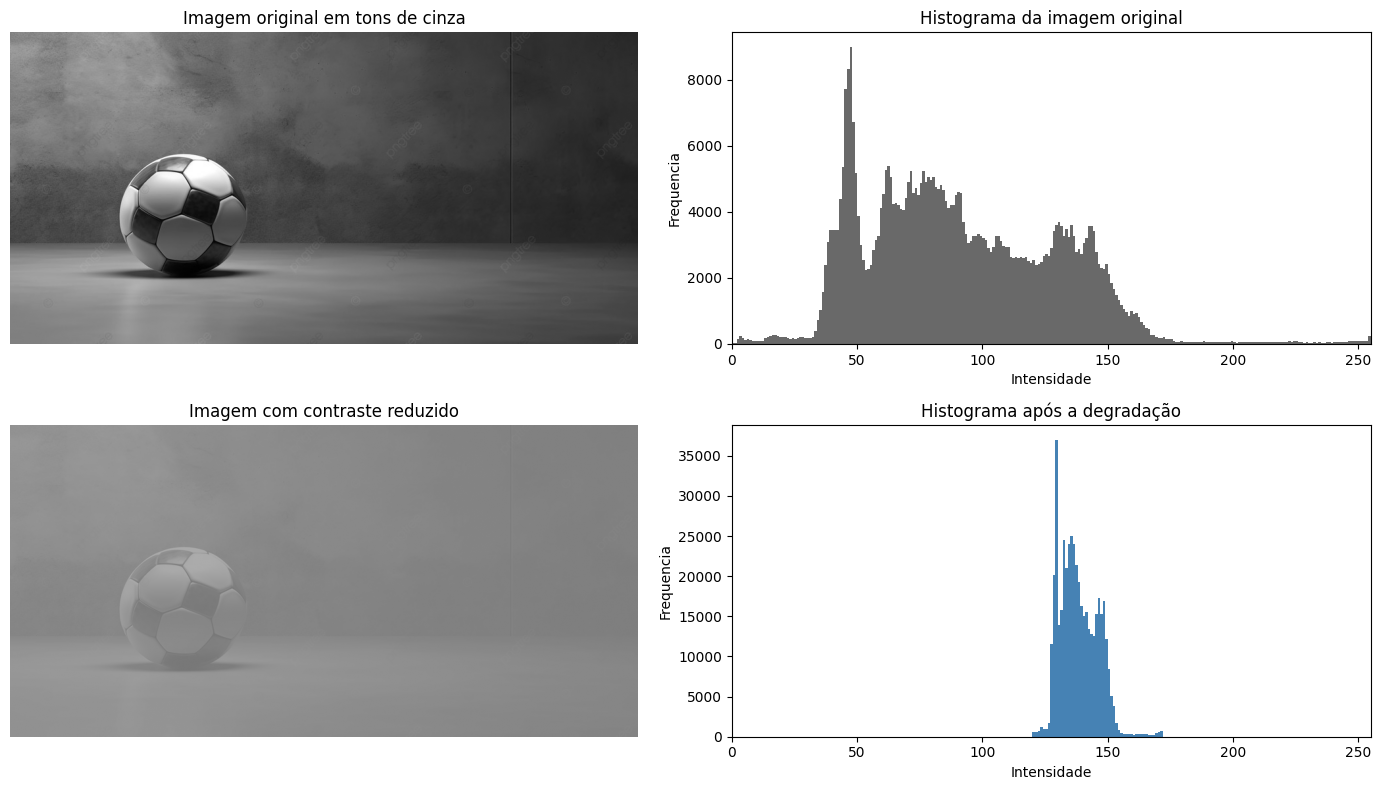

In [ ]:
# reduzindo contraste conforme sugerido
img_baixo_contraste = np.clip((img_cinza.astype(np.float32) * 0.2) + 120, 0, 255).astype(np.uint8)

# criando uma grade 2x2 para mostrar as imagens e histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

mostrar_imagem(axes[0, 0], img_cinza, 'Imagem original em tons de cinza')
mostrar_histograma(axes[0, 1], img_cinza, 'Histograma da imagem original', color='dimgray')
mostrar_imagem(axes[1, 0], img_baixo_contraste, 'Imagem com contraste reduzido')
mostrar_histograma(axes[1, 1], img_baixo_contraste, 'Histograma após a degradação', color='steelblue')
plt.tight_layout()
plt.show()

## **Limiarização base sem pré-processamento**

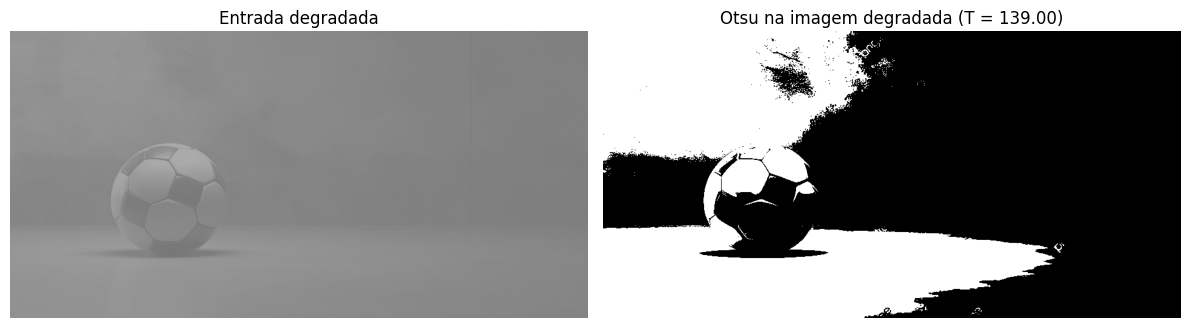

In [ ]:
t, mask = cv2.threshold(
    img_baixo_contraste,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)
y
# criando uma grade 1x2 para mostrar a imagem degradada e o resultado do Otsu
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mostrar_imagem(axes[0], img_baixo_contraste, 'Entrada degradada')
mostrar_imagem(axes[1], mask, f'Otsu na imagem degradada (T = {t:.2f})')
plt.tight_layout()
plt.show()

## **Equalização e re-segmentação**

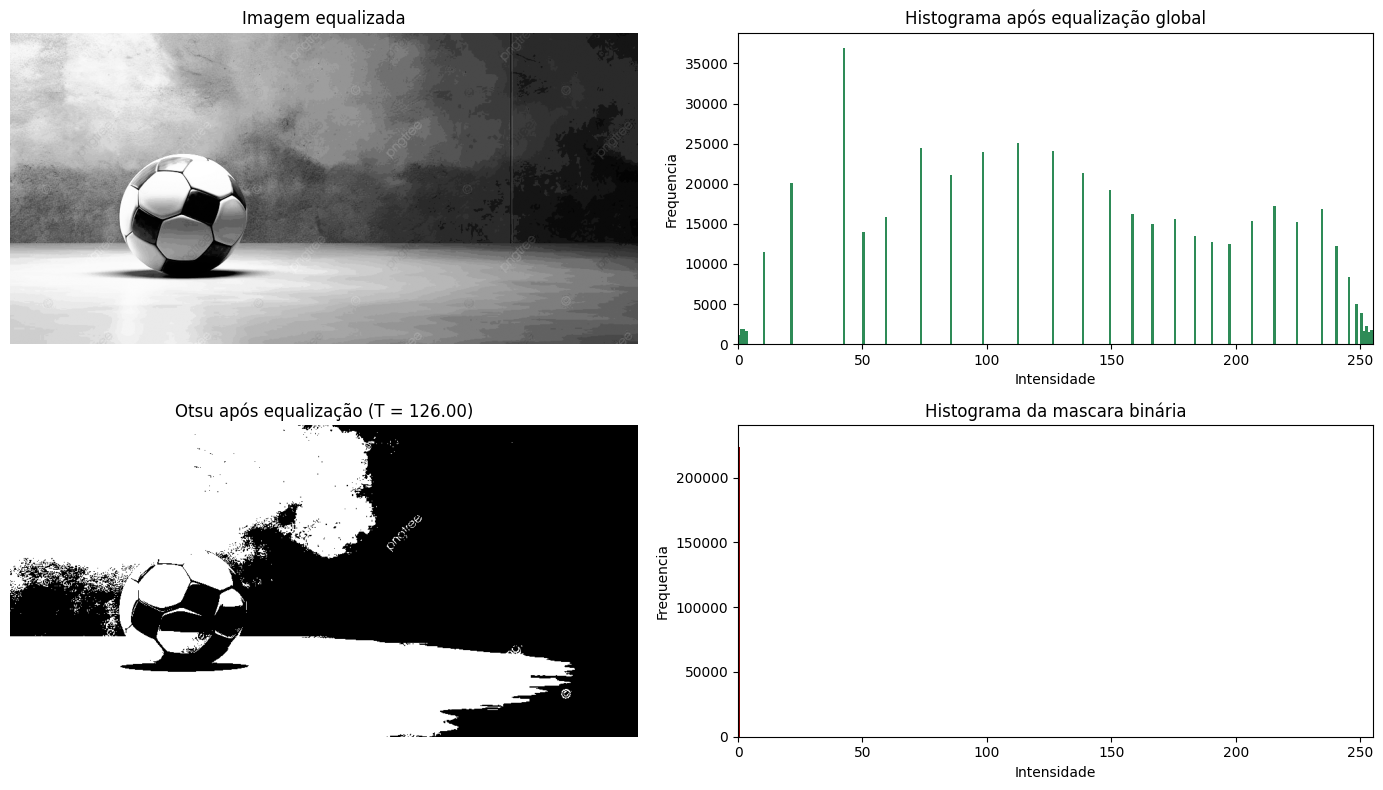

In [14]:
img_equalizada = cv2.equalizeHist(img_baixo_contraste)

t_eq, mask_eq = cv2.threshold(
    img_equalizada,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)

# criando uma grade 2x2 para mostrar as imagens e histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

mostrar_imagem(axes[0, 0], img_equalizada, 'Imagem equalizada')
mostrar_histograma(axes[0, 1], img_equalizada, 'Histograma após equalização global', color='seagreen')
mostrar_imagem(axes[1, 0], mask_eq, f'Otsu após equalização (T = {t_eq:.2f})')
mostrar_histograma(axes[1, 1], mask_eq, 'Histograma da mascara binária', color='darkred')
plt.tight_layout()
plt.show()

## **Desafio Clahe**

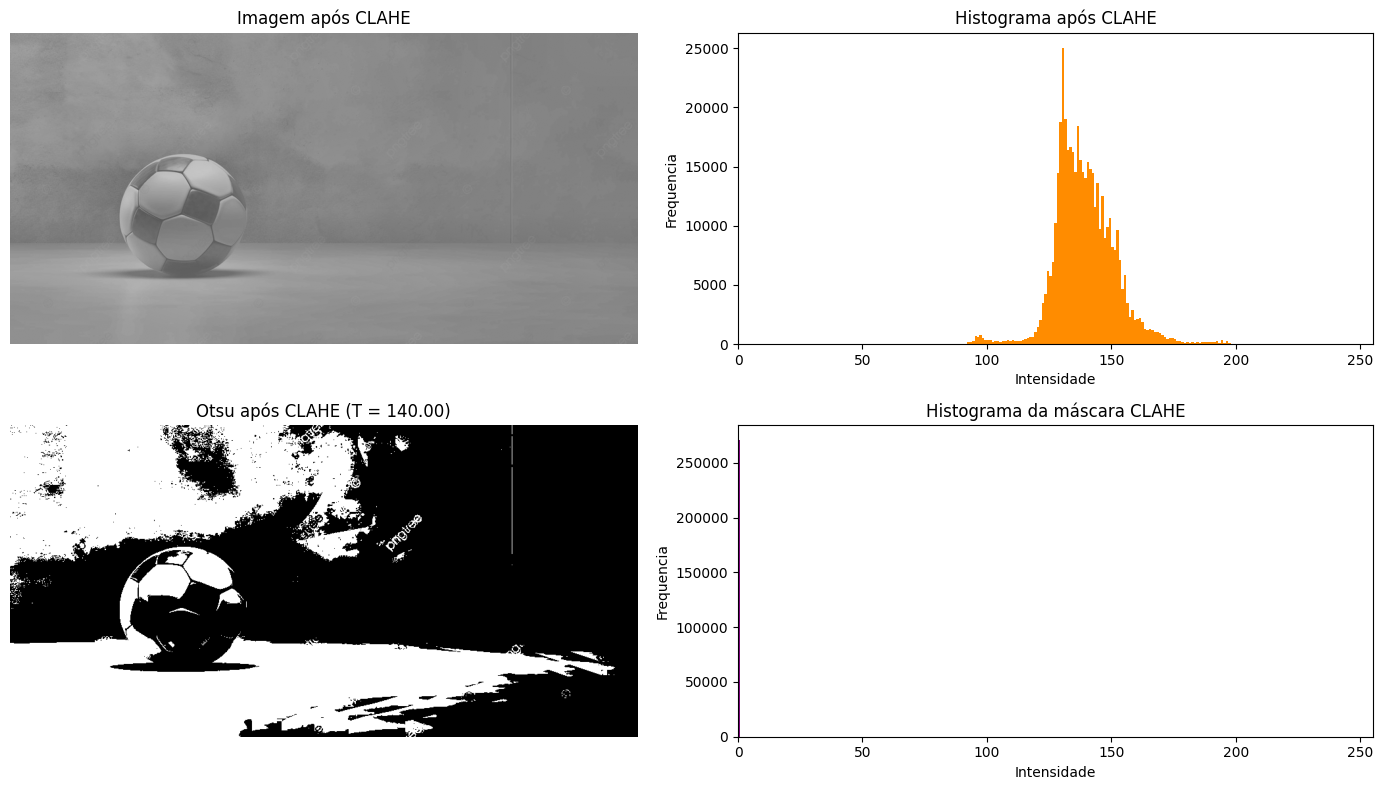

In [16]:
# parâmetros padrão
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# aplicando CLAHE na imagem degradada
img_clahe = clahe.apply(img_baixo_contraste) 

t_clahe, mask_clahe = cv2.threshold(
    img_clahe,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)

# criando uma grade 2x2 para mostrar as imagens e histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 8)) 

mostrar_imagem(axes[0, 0], img_clahe, 'Imagem após CLAHE')
mostrar_histograma(axes[0, 1], img_clahe, 'Histograma após CLAHE', color='darkorange')
mostrar_imagem(axes[1, 0], mask_clahe, f'Otsu após CLAHE (T = {t_clahe:.2f})')
mostrar_histograma(axes[1, 1], mask_clahe, 'Histograma da máscara CLAHE', color='purple')
plt.tight_layout()
plt.show()

## **Comparação final entre as abordagens**

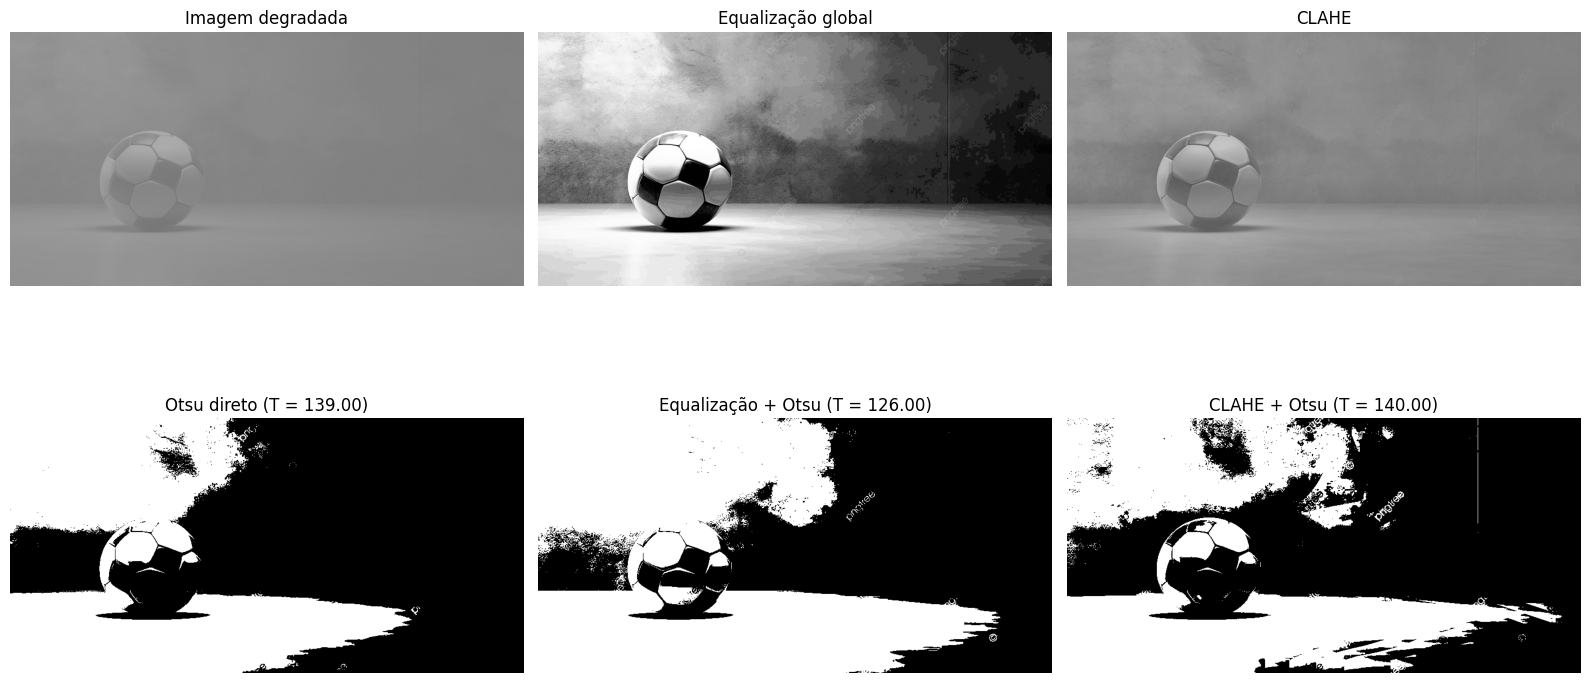

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
mostrar_imagem(axes[0, 0], img_baixo_contraste, 'Imagem degradada')
mostrar_imagem(axes[0, 1], img_equalizada, 'Equalização global')
mostrar_imagem(axes[0, 2], img_clahe, 'CLAHE')
mostrar_imagem(axes[1, 0], mask, f'Otsu direto (T = {t:.2f})')
mostrar_imagem(axes[1, 1], mask_eq, f'Equalização + Otsu (T = {t_eq:.2f})')
mostrar_imagem(axes[1, 2], mask_clahe, f'CLAHE + Otsu (T = {t_clahe:.2f})')
plt.tight_layout()
plt.show()

In [19]:
# salvando saídas (gerado por IA)
saida_dir = img_path.parent

cv2.imwrite(str(saida_dir / '01_baixo_contraste.png'), img_baixo_contraste)
cv2.imwrite(str(saida_dir / '02_otsu_base.png'), mask)
cv2.imwrite(str(saida_dir / '03_equalizada.png'), img_equalizada)
cv2.imwrite(str(saida_dir / '04_otsu_equalizada.png'), mask_eq)
cv2.imwrite(str(saida_dir / '05_clahe.png'), img_clahe)
cv2.imwrite(str(saida_dir / '06_otsu_clahe.png'), mask_clahe)

print(f'Saidas salvas em: {saida_dir}')

Saidas salvas em: /home/andref/Projetos/PDI/atividade_pratica_02


In [21]:
resultados = {
    'limiar_otsu_sem_equalizacao': float(t),
    'limiar_otsu_equalizacao_global': float(t_eq),
    'limiar_otsu_clahe': float(t_clahe),
    'media_original': float(img_cinza.mean()),
    'media_baixo_contraste': float(img_baixo_contraste.mean()),
    'media_equalizada': float(img_equalizada.mean()),
    'media_clahe': float(img_clahe.mean()),
}

resultados

{'limiar_otsu_sem_equalizacao': 139.0,
 'limiar_otsu_equalizacao_global': 126.0,
 'limiar_otsu_clahe': 140.0,
 'media_original': 90.99307884330749,
 'media_baixo_contraste': 137.80230189762963,
 'media_equalizada': 132.64993704022797,
 'media_clahe': 138.80868403030905}